# Import

In [16]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import OllamaLLM
import networkx as nx
from langchain_openai import OpenAI, ChatOpenAI
import tomllib
import json

In [17]:
graph = nx.Graph()

In [18]:
with open("..\secrets.toml", "rb") as f:
    secrets = tomllib.load(f)

In [19]:
# llm = OllamaLLM(model="llama3.2:latest", temperature=0)
# llm_json = OllamaLLM(model="llama3.2:latest", temperature=0, response_format="json")
# llm = OllamaLLM(model="gpt-oss:20b", temperature=0)
# llm_json = OllamaLLM(model="gpt-oss:20b", temperature=0, response_format="json")

llm = ChatOpenAI(model_name="gpt-5-nano", api_key=secrets["api_keys"]["openai"])

# AIML Model Families

In [20]:
prompt = """I am trying to create a graph of AIML models and their explainability methods.
First, I need a list of AIML model families such as 'Classification and Regression Trees', 'Regression','Neural Networks', 'Support Vector Machines', and 'Time-Series', etc.
List out the families of AIML models and they should be exhaustive.
The model families listed should be specific such that algorithms belonging to one particular model family do not fit into another model family.
(e.g., Decision Trees and Random Forests belong to the same family 'Classification and Regression Trees' and not two different families, so they should not be listed seperately).
Also provide a sinlge line description of each model family.
provide the results as a list of json objects with 'name' and 'description' as keys. Do not number them.
Return only the list of json objects and no other text. Do not use any special characters. Use pure json format directly parsable by python json library.
"""
response = llm.invoke(prompt)

In [21]:
model_families = json.loads(response.content)

Here is a response from ChatGPT ([link](https://chatgpt.com/c/68cc39b3-3d4c-8333-ae14-bef0f90e22bf)). We will use these as the AIML Model Family nodes.

In [22]:
import json
[i['name'] for i in model_families]

['Linear Models',
 'Classification and Regression Trees',
 'Support Vector Machines',
 'Neural Networks',
 'Bayesian Methods',
 'Instance-Based Learning',
 'Time-Series',
 'Clustering',
 'Dimensionality Reduction',
 'Reinforcement Learning',
 'Probabilistic Graphical Models',
 'Evolutionary Computation']

In [ ]:
# model_families = ["Linear Models", "Generalized Linear Models", "Classification and Regression Trees", "Rule-Based Models", "Support Vector Machines", "Instance-Based Models", "Ensemble Methods", "Feedforward Neural Networks", "Convolutional Neural Networks", "Recurrent Neural Networks", "Transformer-Based Models", "Probabilistic Graphical Models", "Bayesian Methods", "Evolutionary Algorithms", "Clustering Models", "Dimensionality Reduction Models", "Anomaly Detection Models", "Time-Series Models", "Reinforcement Learning Models"]
# model_families_desc = {
# "Linear Models": "Models that assume a linear relationship between input features and output (e.g., Linear Regression, Perceptron).",
# "Generalized Linear Models": "Extension of linear models allowing non-normal response distributions using link functions (e.g., Logistic Regression, Poisson Regression).",
# "Classification and Regression Trees": "Single decision tree models for classification and regression tasks.",
# "Rule-Based Models": "Models that use human-readable rules for prediction (e.g., RIPPER, OneR, decision lists).",
# "Support Vector Machines": "Models that find optimal separating hyperplanes using kernels for classification or regression.",
# "Instance-Based Models": "Models that rely on similarity to training examples (e.g., k-Nearest Neighbors, Locally Weighted Regression).",
# "Ensemble Methods": "Models that combine multiple base learners to improve performance (e.g., Bagging, Boosting, Stacking).",
# "Feedforward Neural Networks": "Basic multi-layer perceptrons with fully connected layers, mapping input to output directly.",
# "Convolutional Neural Networks": "Neural networks specialized for grid-structured data like images, using convolutional layers.",
# "Recurrent Neural Networks": "Neural networks with feedback connections designed for sequential data (e.g., LSTM, GRU).",
# "Transformer-Based Models": "Attention-based neural networks, including large language models (e.g., GPT, BERT, T5).",
# "Probabilistic Graphical Models": "Graph-based models capturing dependencies among variables (e.g., Bayesian Networks, Markov Random Fields).",
# "Bayesian Methods": "Models using Bayes’ theorem to update beliefs with evidence (e.g., Naive Bayes, Bayesian inference).",
# "Evolutionary Algorithms": "Optimization algorithms inspired by natural selection (e.g., Genetic Algorithms, Genetic Programming).",
# "Clustering Models": "Unsupervised models grouping data points based on similarity (e.g., K-Means, DBSCAN, Hierarchical Clustering).",
# "Dimensionality Reduction Models": "Models that reduce feature space while preserving structure (e.g., PCA, t-SNE, Autoencoders).",
# "Anomaly Detection Models": "Models identifying unusual or rare patterns that deviate from expected behavior.",
# "Time-Series Models": "Models capturing temporal dependencies and trends (e.g., ARIMA, Prophet, RNN-based forecasting).",
# "Reinforcement Learning Models": "Models that learn policies through interaction with an environment using rewards and penalties."
# }

In [23]:
graph.add_nodes_from([(i['name'], {'description': i['description']}) for i in json.loads(response.content)], type='AIML Model Family')

In [24]:
graph.nodes(data=True)

NodeDataView({'Linear Models': {'type': 'AIML Model Family', 'description': 'Models that assume a linear relationship between inputs and outputs; includes linear regression, logistic regression and generalized linear models with regularization.'}, 'Classification and Regression Trees': {'type': 'AIML Model Family', 'description': 'Tree based models that use recursive splits to model data; encompasses decision trees and tree ensembles such as random forests and gradient boosting.'}, 'Support Vector Machines': {'type': 'AIML Model Family', 'description': 'Models that find hyperplanes to separate classes or regress continuous targets using kernel tricks.'}, 'Neural Networks': {'type': 'AIML Model Family', 'description': 'Parametric models composed of layered neurons capable of learning complex nonlinear mappings.'}, 'Bayesian Methods': {'type': 'AIML Model Family', 'description': 'Probability based approaches that incorporate prior beliefs and update with data to form posterior distributi

In [ ]:
# import pickle
# with open('..\graph.pkl', 'wb') as file:
#     pickle.dump(graph, file)


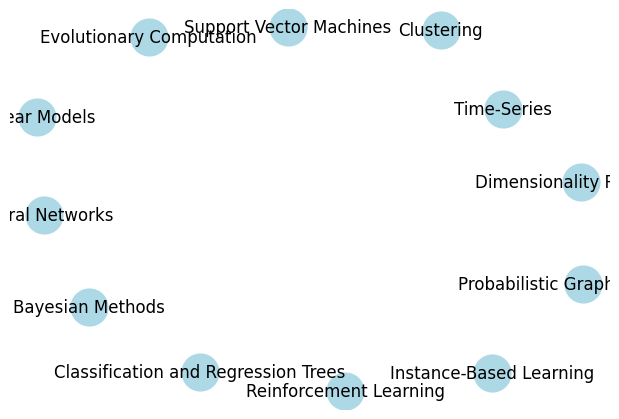

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
nx.draw(graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)
plt.show()

# AIML Model Algorithms

## Getting Algorithms

In [27]:
models_prompt = PromptTemplate.from_template("""List 5-10 popular algorithms belonging to the AIML model family '{model_family}'.
                                             Here is a description of the type of models that belong to this family: {model_family_desc}.
                                             Also provide a sinlge line description of each model family.
                                             Provide the results as a list of json objects with 'name' and 'description' as keys. Do not number them.
                                             Return only the list of json objects and no other text. Do not use any special characters. Use pure json format directly parsable by python json library.""")

In [28]:
model_chain = models_prompt | llm | StrOutputParser()
nodes = []
edges = []
for model_fam in model_families:
    response = model_chain.invoke({'model_family': model_fam['name'], 'model_family_desc': model_fam['description']})
    # print(response)
    models = json.loads(response)
    for model in models:
        nodes.append((model['name'], {'description': model['description']}))
        edges.append((model_fam['name'], model['name'], {'relationship': 'has_model'}))

In [29]:
print(nodes)
print(edges)

[('Linear Regression', {'description': 'Fits a linear function to predict a continuous target by minimizing the sum of squared residuals.'}), ('Logistic Regression', {'description': 'Models the probability of a binary outcome using a logistic function over a linear combination of inputs.'}), ('Ridge Regression', {'description': 'Linear regression with L2 regularization that shrinks coefficients to reduce overfitting.'}), ('Lasso Regression', {'description': 'Linear regression with L1 regularization that promotes sparse feature selection.'}), ('Elastic Net Regression', {'description': 'Linear regression with a combination of L1 and L2 regularization to balance sparsity and stability.'}), ('Polynomial Regression', {'description': 'Linear model that uses polynomial features to capture nonlinear relationships while remaining linear in coefficients.'}), ('Bayesian Linear Regression', {'description': 'A probabilistic linear model that infers distributions over coefficients and predictions.'}

In [30]:
graph.add_nodes_from(nodes, type='AIML Model Algorithm')
graph.add_edges_from(edges)

In [ ]:
# import pickle
# with open('..\graph2.pkl', 'wb') as file:
#     pickle.dump(graph, file)

TypeError: dump() missing required argument 'file' (pos 2)

In [31]:
graph.nodes(data=True)

NodeDataView({'Linear Models': {'type': 'AIML Model Family', 'description': 'Models that assume a linear relationship between inputs and outputs; includes linear regression, logistic regression and generalized linear models with regularization.'}, 'Classification and Regression Trees': {'type': 'AIML Model Family', 'description': 'Tree based models that use recursive splits to model data; encompasses decision trees and tree ensembles such as random forests and gradient boosting.'}, 'Support Vector Machines': {'type': 'AIML Model Family', 'description': 'Models that find hyperplanes to separate classes or regress continuous targets using kernel tricks.'}, 'Neural Networks': {'type': 'AIML Model Family', 'description': 'Parametric models composed of layered neurons capable of learning complex nonlinear mappings.'}, 'Bayesian Methods': {'type': 'AIML Model Family', 'description': 'Probability based approaches that incorporate prior beliefs and update with data to form posterior distributi

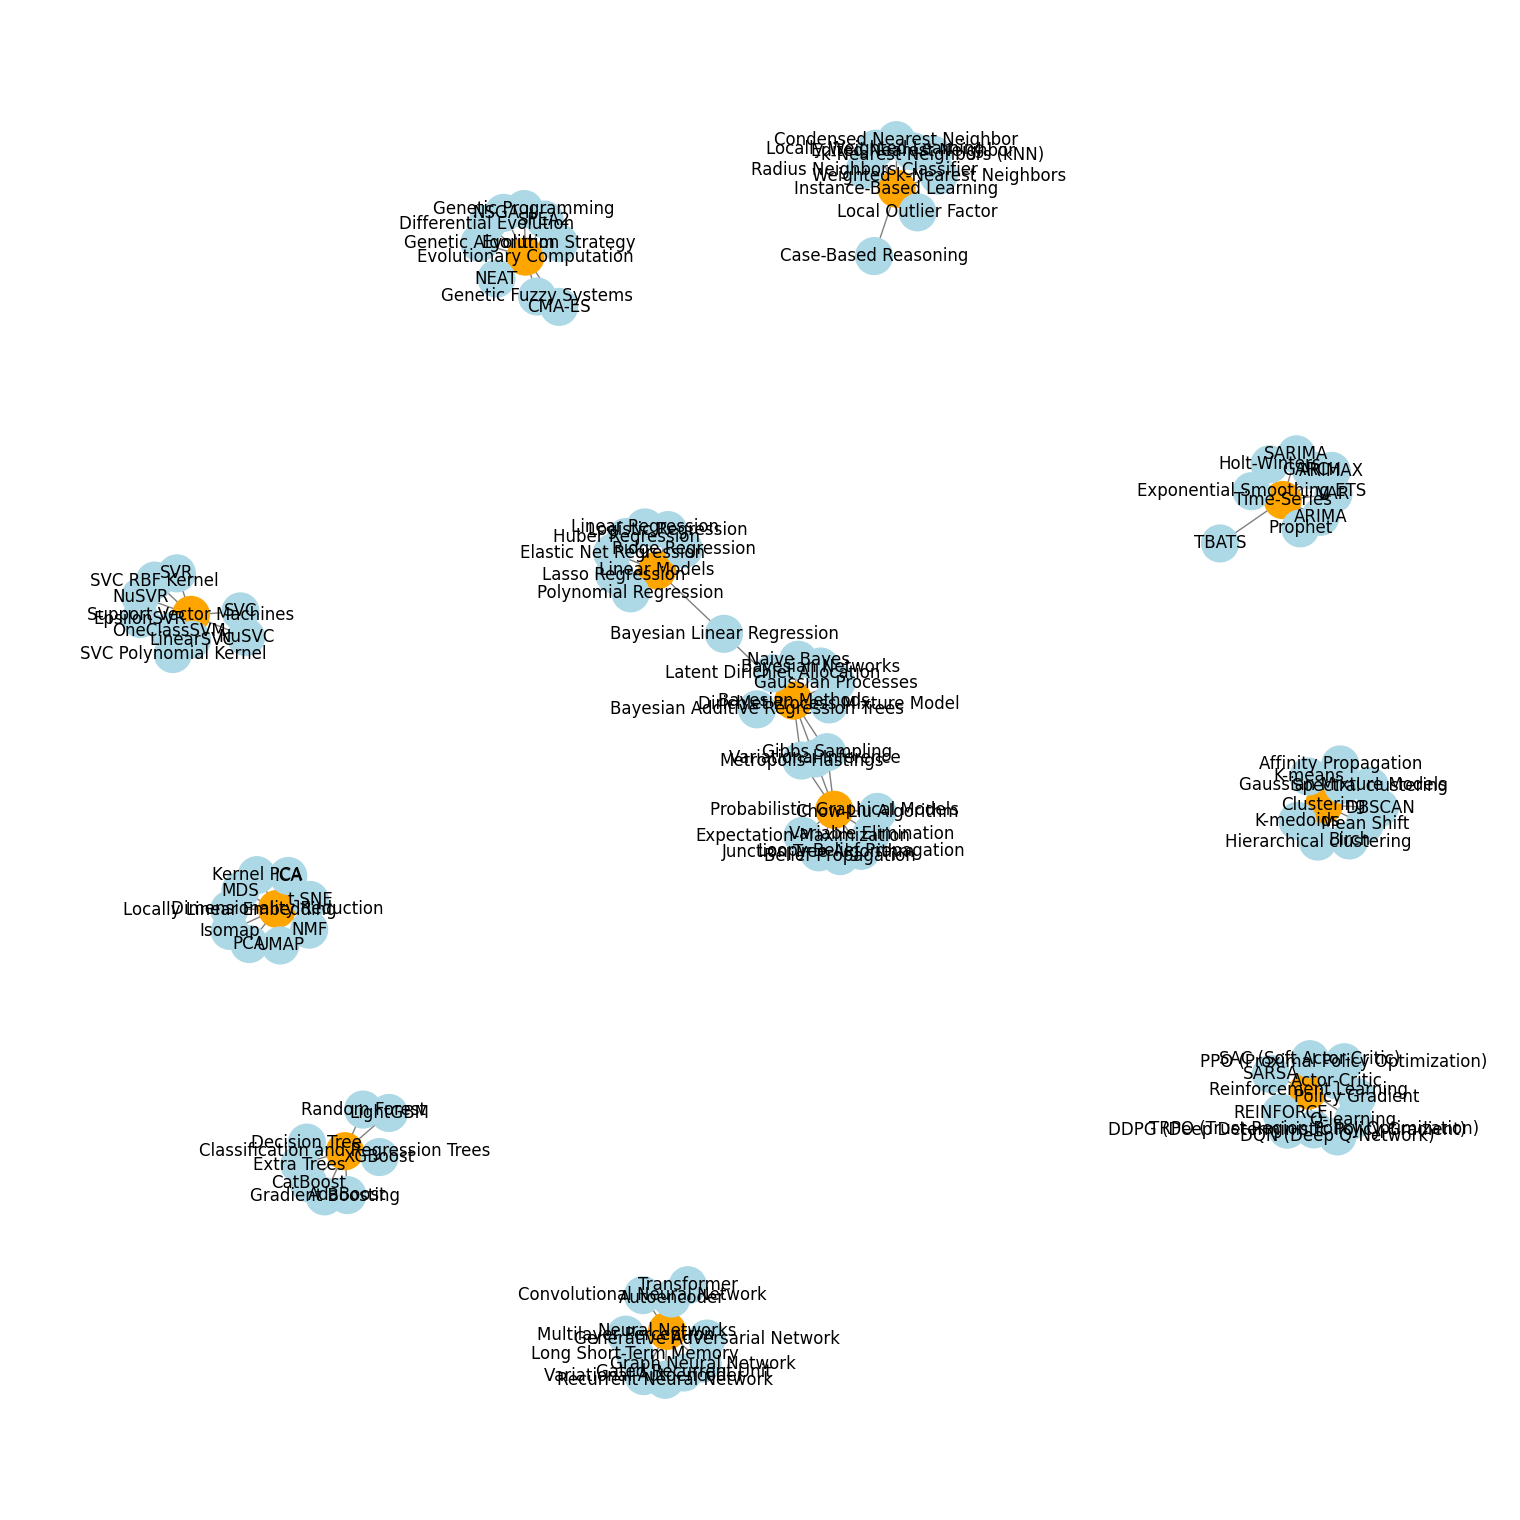

In [32]:
import matplotlib.pyplot as plt


colors = []

for node, data in graph.nodes(data=True):
    if data.get('type') == 'AIML Model Family':
        colors.append('orange')
    elif data.get('type') == 'AIML Model Algorithm':
        colors.append('lightblue')


plt.figure(figsize=(15, 15))
nx.draw(graph, with_labels=True, node_color=colors, edge_color='gray', node_size=700)
plt.show()

# Explainability Methods

In [33]:
prompt = """List 5-10 popular explainability methods for AIML models within the {model_family} model family.
            Example models in this family include {models}.
            Also provide a sinlge line description of each model explainability technique.
            Provide the results as a list of json objects with 'name' and 'description' as keys. Do not number them.
            Return only the list of json objects and no other text. Do not use any special characters. Use pure json format directly parsable by python json library."""

In [34]:
explainability_model_chain = PromptTemplate.from_template(prompt) | llm | StrOutputParser()
explainability_nodes = []
for model_fam in model_families:
    # Get models in this family
    response = model_chain.invoke({'model_family': model_fam['name'], 'model_family_desc': model_fam['description']})
    models = [i['name'] for i in json.loads(response)]
    models_str = ', '.join(models)
    # Get explainability methods for these models
    response = explainability_model_chain.invoke({'model_family': model_fam['name'], 'models': models_str})
    explainability_methods = json.loads(response)
    for method in explainability_methods:
        if method['name'] not in [n[0] for n in explainability_nodes]:
            explainability_nodes.append((method['name'], {'description': method['description']}))
        edges.append((model_fam['name'], method['name'], {'relationship': 'has_explainability_method'}))

In [37]:
len(explainability_nodes)

94

In [38]:
graph.add_nodes_from(explainability_nodes, type='Explainability Method')

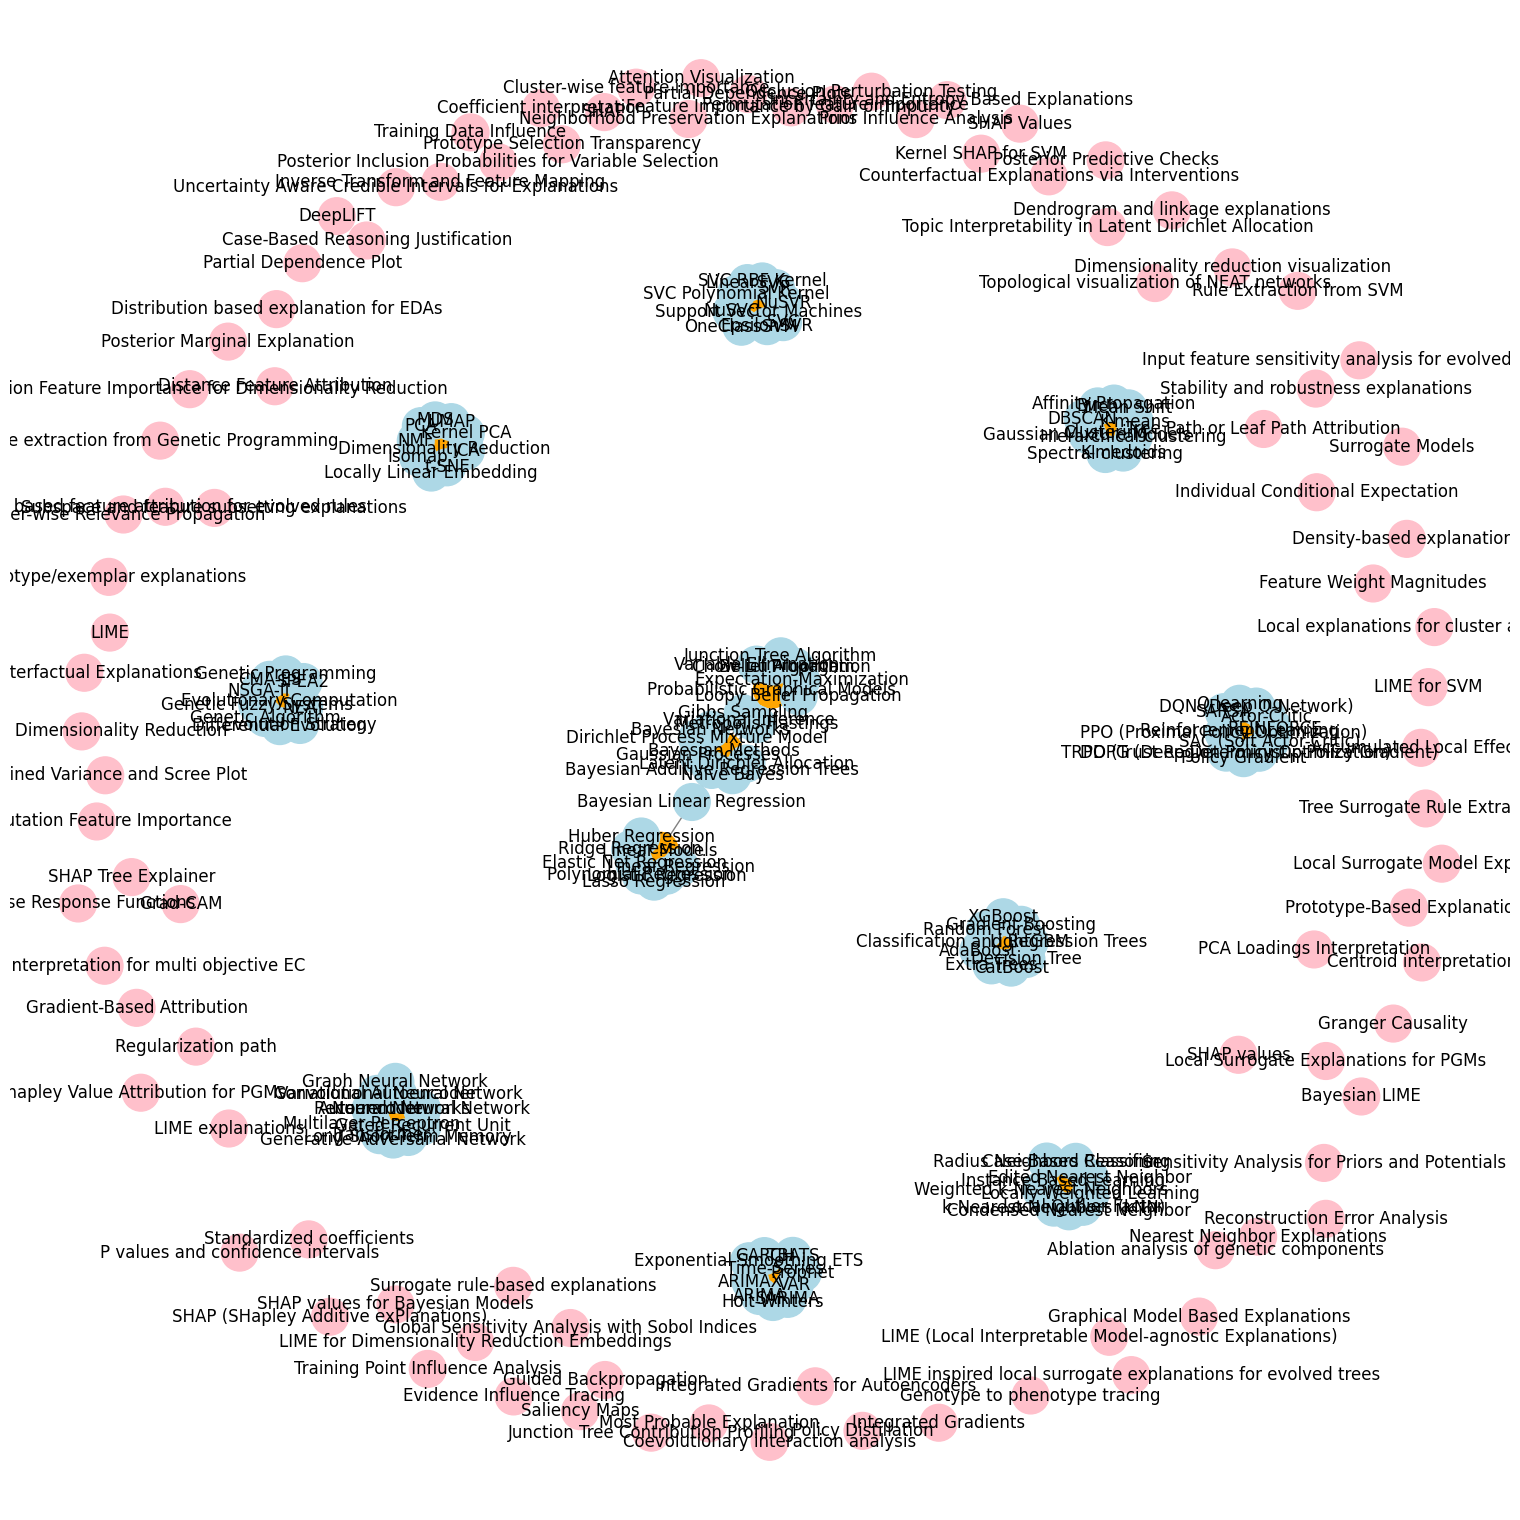

In [39]:
import matplotlib.pyplot as plt


colors = []

for node, data in graph.nodes(data=True):
    if data.get('type') == 'AIML Model Family':
        colors.append('orange')
    elif data.get('type') == 'AIML Model Algorithm':
        colors.append('lightblue')
    elif data.get('type') == 'Explainability Method':
        colors.append('pink')


plt.figure(figsize=(15, 15))
nx.draw(graph, with_labels=True, node_color=colors, edge_color='gray', node_size=700)
plt.show()

In [ ]:
# import pickle
# with open('..\graph3.pkl', 'wb') as file:
#     pickle.dump(graph, file)

In [48]:
def group(data, num):
    return [data[i:i + num] for i in range(0, len(data), num)]

In [53]:
methods = [(i[0], {'description':i[1]["description"]}) for i in graph.nodes(data=True) if i[1]['type'] == 'Explainability Method']
grouped_methods = group(methods, 5)

In [41]:
model_algorithms = [i for i in list(graph.nodes(data=True)) if i[1]['type']=='AIML Model Algorithm']

In [55]:
prompt = """Here is a list of explainability methods for AIML models and brief descriptions: {methods}.
Out of these, which ones are best suited for explaining the {model_algorithm} model?
Provide a brief explanation of how each selected method would be applied.
Return the results as a list of json objects with 'name' and 'application' as keys.
If none of the methods are suitable, return an empty list.
"""

In [56]:
methods_mapping_chain = PromptTemplate.from_template(prompt) | llm | StrOutputParser()

In [ ]:
# methods_mapping_chain.invoke({'methods': grouped_methods[0], 'model_algorithm': 'Linear Regression'})

'[\n  {\n    "name": "Coefficient interpretation",\n    "application": "In linear regression, each coefficient beta_j indicates the expected change in the target for a one unit increase in feature X_j, with all other features held constant. Explain the sign, magnitude, and the units of the effect, and note any interpretation caveats due to multicollinearity or interactions."\n  },\n  {\n    "name": "Standardized coefficients",\n    "application": "Standardize features (and the target if desired) before fitting the model to obtain coefficients in units of standard deviations. Compare magnitudes across features to assess relative importance when features are on different scales."\n  },\n  {\n    "name": "P values and confidence intervals",\n    "application": "Use the regression output to report p-values and confidence intervals for each coefficient. Interpret statistical significance and the precision of estimates, while considering model assumptions and potential multicollinearity."\n 

In [ ]:
model_methods = {}
failed = []

for model in model_algorithms:
    print(f"Processing model: {model[0]}")
    applicable_methods = []
    for method_group in grouped_methods:
        response = methods_mapping_chain.invoke({'methods': method_group, 'model_algorithm': model[0]})
        try:
            selected_methods = json.loads(response)
            applicable_methods.extend(selected_methods)
        except:
            print(f"Failed to parse response for model {model[0]} and methods group {method_group}")
            failed.append((model[0], method_group))
    model_methods[model[0]] = applicable_methods

Processing model: Linear Regression
Processing model: Logistic Regression
Processing model: Ridge Regression
Processing model: Lasso Regression
Processing model: Elastic Net Regression
Processing model: Polynomial Regression
Processing model: Bayesian Linear Regression
Processing model: Huber Regression
Processing model: Decision Tree
Processing model: Random Forest
Processing model: Gradient Boosting
Failed to parse response for model Gradient Boosting and methods group [('Dimensionality reduction visualization', {'description': 'Project data with PCA, t-SNE, or UMAP to visualize and interpret cluster separation in 2D/3D space.'}), ('Dendrogram and linkage explanations', {'description': 'Explain hierarchical clustering results via the dendrogram structure, linkage criteria, and the chosen cut level.'}), ('Density-based explanations', {'description': 'Explain DBSCAN/HDBSCAN clusters through core points, reachability, and density-based justification for cluster membership and noise.'}),

In [ ]:
import pickle
with open('..\model_method_mapping.pkl', 'wb') as file:
    pickle.dump({"model_methods": model_methods, "failed": failed}, file)

In [ ]:
edges = []
for model, methods in model_methods.items():
    for method in methods:
        edges.append((model, method['name'], {'relationship': 'explained_by', 'application': method['application']}))

In [ ]:
graph.add_edges_from(edges)

In [ ]:
import pickle
with open('..\graph4.pkl', 'wb') as file:
    pickle.dump(graph, file)

In [ ]:
failed

In [ ]:
len(failed)

## Getting Information

In [17]:
from ddgs import DDGS
from bs4 import BeautifulSoup
import requests

# Searching
search_results = DDGS().text("Perceptron Python Library Documentation", max_results=5)
links = [result['href'] for result in search_results]
links
print(links)

# Fetching and parsing
response = requests.get(links[0])
soup = BeautifulSoup(response.content, 'html.parser')
content = soup.get_text(separator="\n", strip=True)

info_prompt = PromptTemplate.from_template("""From the following context, extract information about the AIML algorithm '{algorithm}'.
                                           Look for the python library name the algorithm belongs to and the class name used in that library.
                                           If no such information is found, return 'No information found'.
                                           If information is available return only the json response and no text before or after the json.
                                           Here is the context: {content}
                                           Provide the output as a dictionary in the following json format:
                                           {{'library': <library_name>, 'class': <class_name>}}
                                           Return only the json response and no other text or special characters.""")

info_chain = info_prompt | llm_json | StrOutputParser()
info_chain.invoke({'algorithm': 'Perceptron', 'content': content})

['https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html', 'https://www.geeksforgeeks.org/machine-learning/sklearn-perceptron/', 'https://pypi.org/project/Python-Perceptron/', 'https://python.plainenglish.io/building-a-perceptron-from-scratch-a-step-by-step-guide-with-python-6b8722807b2e', 'https://sharpsight.ai/blog/python-perceptron-from-scratch/']


'{\n    "library": "scikit-learn",\n    "class": "Perceptron"\n}'

In [18]:
desc_prompt = PromptTemplate.from_template("""Provide a short description on the AIML algorithm '{algorithm}'.
                                             Return only the description text and no other text.""")
description_chain = desc_prompt | llm | StrOutputParser()
# description_chain.invoke({'algorithm': 'Linear Regression'})

In [19]:
algos = {}

for fam, algs in models.items():
    for alg in algs:
        if algos.get(alg) is None:
            desc = description_chain.invoke({'algorithm': alg})
            algos[alg]['desc'] = desc
            # graph.add_node(alg, type='AIML Model Algorithm', description=desc)

KeyError: 'Linear Regression'

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 20))
# nx.draw(graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)
# plt.show()